# Proxy metrics - hw
## Libraries and functions

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
from tqdm import tqdm

In [58]:
# напишем функцию, которая проверяет наличие корреляции
# между категориальной и количественной переменной
def find_cat_quant_correlation(quant_value, binary_mask, plot = True, print_inference = True):
    '''
    quant_value - количественная переменная,  для которой считаем корреляцию
    binary_mask - бинарная переменная (True, False), для которой считаем корреляцию
    plot - надо ли отрисовывать график
    print_inference - надо ли принтовать выводы и основные метркии
    '''

    # разбиваем количественную метрику на группы по тому, была ли целевая конверсия или нет
    group_1 = quant_value[binary_mask] # binary = 1
    group_2 = quant_value[~binary_mask] # binary = 0

    # считаем pointbiserial корреляцию, тест Краскелла-Уолесса и обычный Т-тест
    pointbiserialr = ss.pointbiserialr(quant_value, binary_mask)[0]
    kruskal_pval = ss.kruskal(group_1, group_2)[1]
    ttest_pval = ss.ttest_ind(group_1, group_2)[1]

    # принтуем выводы
    if print_inference:
        print('Mean quant value for group (binary=1) =', group_1.mean())
        print('Mean quant value for group (binary=0) =', group_2.mean())

        print('Median quant value for group (binary=1) =', group_1.median())
        print('Median quant value for group (binary=0) =', group_2.median())

        print('Kruskal-Wallis H Test p-value =', kruskal_pval)
        print('T-test p-value =', ttest_pval)
        print('point biserial correlation =', pointbiserialr)

    # рисуем график распределения для двух групп, чтобы проиллюстрировать различия в группах
    if plot:
        plt.figure(figsize=(16,6))
        sns.kdeplot(group_1, color = 'red', label = 'Binary = True')
        sns.kdeplot(group_2, color = 'blue', label = 'Binary = False')
        plt.axvline(x = group_1.mean(), linestyle = '--', color = 'red')
        plt.axvline(x = group_2.mean(), linestyle = '--', color = 'blue')
        plt.legend()

    return({'point biserial R':pointbiserialr,
            'kruskal_pval':kruskal_pval,
            'ttest_pval':ttest_pval})

# напишем функцию для визуализации и поиска оптимальных порогов для создания прокси-метрики
def proxy_metrics_bins_analizer(quant_value, binary_mask, step):

    #разбиваем исходную количественную величину на квантили с нужным шагом
    deciles_bins = np.quantile(quant_value, np.arange(0, 1, step))
    
    #разбиваем ряд на бины
    inds = np.digitize(quant_value, deciles_bins, right = False)
    
    # агрегируем
    df = pd.DataFrame({'quant_value':quant_value,
                  'binary': binary_mask,
                  'bins': inds})
    
    inference = df.groupby('bins').mean()

    #считаем point biserial корреляцию
    point_biserial_R = find_cat_quant_correlation(quant_value = quant_value, binary_mask=binary_mask, plot = False, print_inference = False)['point biserial R']

    # рисуем график
    # plt.figure(figsize=(12,6))
    # sns.lineplot(y = inference['quant_value'], x = inference.index*step, color = 'red', label = 'quant_value')
    # plt.axhline(y = quant_value.median(), linestyle = '--', color = 'red')
    # plt.text(x = inds.mean()*step, y = np.quantile(quant_value, 0.95), s ='point_biserial_R = {}'.format(point_biserial_R), )
    # ax2 = plt.twinx()
    # sns.lineplot(y = inference['binary'], x = inference.index*step, color = 'blue', label = 'binary share', ax=ax2)
    # plt.axhline(y = binary_mask.mean(), linestyle = '--', color = 'blue')
    # ax2.legend(loc='upper right')
    # # plt.legend()
    
    # рисуем график
    plt.figure(figsize=(12,6))
    
    # Линия для quant_value
    line1 = sns.lineplot(y=inference['quant_value'], x=inference.index*step, color='red', label='quant_value')
    plt.axhline(y=quant_value.median(), linestyle='--', color='red')
    plt.text(x=inds.mean()*step, y=np.quantile(quant_value, 0.95), s='point_biserial_R = {}'.format(point_biserial_R))
    
    # Вторая ось для binary share
    ax2 = plt.twinx()
    line2 = sns.lineplot(y=inference['binary'], x=inference.index*step, color='blue', label='binary share', ax=ax2)
    plt.axhline(y=binary_mask.mean(), linestyle='--', color='blue')
    
    # Объединяем обе легенды
    lines = [line1.lines[0], line2.lines[0]]
    labels = ['quant_value', 'binary share']
    plt.legend(lines, labels, loc='upper left')
    
    plt.show()

#создадим функцию для оценки ассоциации двух бинарных переменных
def cramers_v(confusion_matrix):
    """ calculate Cramers V statistic for categorial-categorial association.
        uses correction from Bergsma and Wicher,
        Journal of the Korean Statistical Society 42 (2013): 323-328
    """
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    return (cramers_v)

#попробуем найти порог, при котором коэффициент ассоциации cramer V будет максимальным
def max_cramerv_corr_finder(quant_value, binary_mask, plot = True, print_inference = True, step = 1):
    '''
    quant_value - исходная количественная переменная по которой мы пытаемся найти порог
    binary_mask - бинарная метрика с целевой конверсией к которой мы исщем максимальную корреляцию
    plot - нужно ли рисовать граиф
    print_inference - нужно ли принтовать выводы
    step - размер шага с которым мы идем по quant_value и определяем пороги
    '''
    # определяем вектор исходной количественной переменной, на котором мы будет искать максимальную корреляцию
    arange = np.arange(min(quant_value), max(quant_value), step)
    cramers_v_list = []

    #циклом проходим по всем порогам и находим значение cramers_v
    for i in arange:
        confusion_matrix = pd.crosstab(binary_mask, quant_value>i)
        cramers_v_i = cramers_v(confusion_matrix.values)
        cramers_v_list.append(cramers_v_i)

    # сохраняем максимальные найденные значения корреляции и порога, при котором она достигается
    max_corr_quant_value = arange[np.argmax(np.array(cramers_v_list))]
    max_cramer_v = max(cramers_v_list)

    # отрисовываем график
    if plot:
        sns.lineplot(x = arange, y = cramers_v_list)
        plt.axhline(y = np.array(cramers_v_list).max(), linestyle = '--', color = 'red')
        plt.axvline(x = max_corr_quant_value, linestyle = '--', color = 'red')
        plt.xlabel('quant values')
        plt.ylabel('Cramer-V')

    ## принтуем выводы
    if print_inference:
        print('Maximum Cramer V =', np.array(cramers_v_list).max())
        print('Maximum Cramer V quant value = ', max_corr_quant_value)

    return({'max_cramer_v': max_cramer_v,
           'max_corr_quant_value': max_corr_quant_value})

In [43]:
def standartized(arr:np.array):
    return ((arr - arr.mean())/arr.std(ddof=1))

0       0.053564
1       4.602481
2       0.053564
3      -0.596282
4       0.703409
          ...   
2931    0.703409
2932    0.053564
2933    0.703409
2934   -0.596282
2935    1.353254
Name: last_7_contacts, Length: 2936, dtype: float64

# Read data

Также команда достала определенные метрики, которые могут быть полезны для поиска прокси-метрики:
- `user_id` — пользователя;
- `views` — суммарное количество просмотров объявлений за весь период активности в классифайде на момент ухода искателя в отток;
- `contacts` — суммарное количество контактов по объявлениям (просмотры телефона и написанные сообщения) за весь период активности в классифайде на момент ухода в отток;
- `last_7_views` — просмотры за 7 дней до ухода в отток;
- `last_3_views` — просмотры за 3 дня до ухода в отток;
- `last_7_contacts` — контакты за 7 дней до ухода в отток;
- `last_3_contacts` — контакты за 3 дня до ухода в отток;
- `live_days` — длительность в днях с первого момента появления в продукте до ухода в отток;
- `messages_events` — количество написанных сообщений искателем;
- `add_to_favor_events` — количество добавленных объявлений в избранное;
- `max_views_delta` — разница между самым малоактивным в просмотрах днем (но не нулевым) и самым активным днем в просмотрах.

In [11]:
df_data = pd.read_csv('./data/proxy_metrics_homework.csv')

print(df_data.info(verbose=False))
print('*'*30)
print(df_data.columns)
print('*'*30)
print(df_data.isna().sum())
print('*'*30)
print(df_data.dtypes)
print('*'*30)
df_data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Columns: 12 entries, is_bought to max_views_delta
dtypes: float64(8), int64(4)
memory usage: 275.4 KB
None
******************************
Index(['is_bought', 'user_id', 'views', 'contacts', 'last_7_views',
       'last_3_views', 'last_7_contacts', 'last_3_contacts', 'live_days',
       'messages_events', 'add_to_favor_events', 'max_views_delta'],
      dtype='object')
******************************
is_bought              0
user_id                0
views                  0
contacts               0
last_7_views           0
last_3_views           0
last_7_contacts        0
last_3_contacts        0
live_days              0
messages_events        0
add_to_favor_events    0
max_views_delta        0
dtype: int64
******************************
is_bought                int64
user_id                  int64
views                  float64
contacts               float64
last_7_views           float64
last_3_views           fl

,is_bought,user_id,views,contacts,last_7_views,last_3_views,last_7_contacts,last_3_contacts,live_days,messages_events,add_to_favor_events,max_views_delta
0,0,147929483,268.0,4.0,86.0,35.0,1.0,0.0,30,44,68.0,1.0
1,1,150687565,641.0,7.0,705.0,437.0,8.0,4.0,9,41,101.0,1.0
2,0,150610724,111.0,2.0,60.0,34.0,1.0,1.0,16,43,4.0,3.0
3,0,149537757,287.0,3.0,31.0,16.0,0.0,0.0,29,66,18.0,1.0
4,1,149711357,516.0,3.0,210.0,141.0,2.0,1.0,25,82,85.0,1.0


# Main tasks

* провести корреляционный анализ;
* доработать первичный список;
* проверить мощность и уровень значимости теста;
* проверить на реальном АБ-тесте, позволяет ли прокси-метрика детектить изменение целевой метрики. Анализ чувствительности прокси-метрики.


## Correlation analysis

### views

Mean quant value for group (binary=1) = 137.0840807174888
Mean quant value for group (binary=0) = 97.7578277886497
Median quant value for group (binary=1) = 77.0
Median quant value for group (binary=0) = 56.0
Kruskal-Wallis H Test p-value = 5.926372420292206e-12
T-test p-value = 2.201854182147229e-11
point biserial correlation = 0.12308511940193985


{'point biserial R': np.float64(0.12308511940193985),
 'kruskal_pval': np.float64(5.926372420292206e-12),
 'ttest_pval': np.float64(2.201854182147229e-11)}

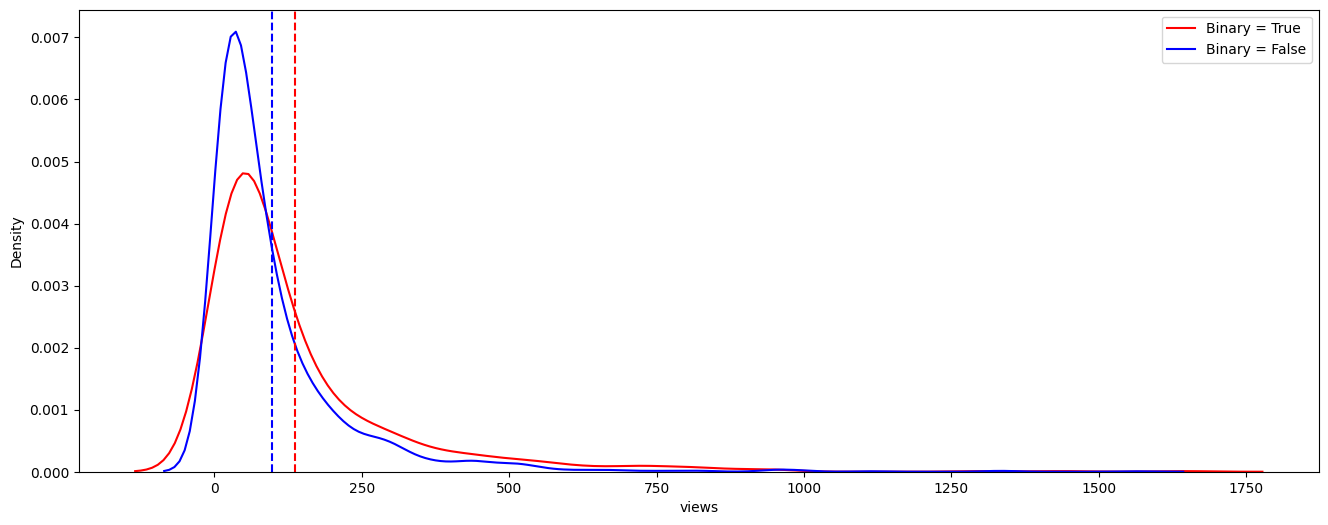

In [7]:
find_cat_quant_correlation(quant_value=df_data.views, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

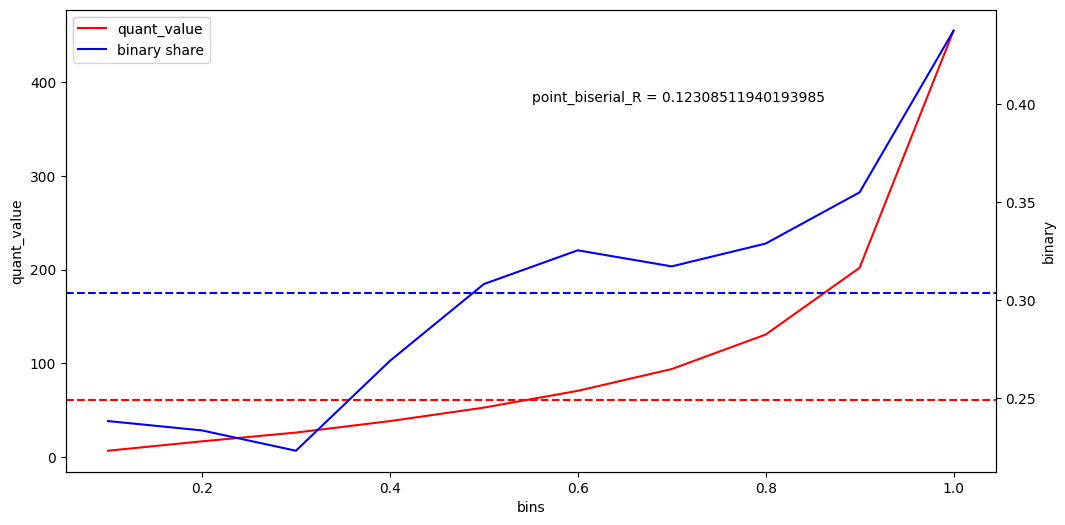

In [8]:
proxy_metrics_bins_analizer(quant_value=df_data.views, binary_mask=df_data.is_bought==1, step=0.1)

### contacts

Mean quant value for group (binary=1) = 1.84304932735426
Mean quant value for group (binary=0) = 0.9867906066536204
Median quant value for group (binary=1) = 1.0
Median quant value for group (binary=0) = 0.0
Kruskal-Wallis H Test p-value = 5.242919596537224e-38
T-test p-value = 6.190430331990223e-19
point biserial correlation = 0.16301246824628413


{'point biserial R': np.float64(0.16301246824628413),
 'kruskal_pval': np.float64(5.242919596537224e-38),
 'ttest_pval': np.float64(6.190430331990223e-19)}

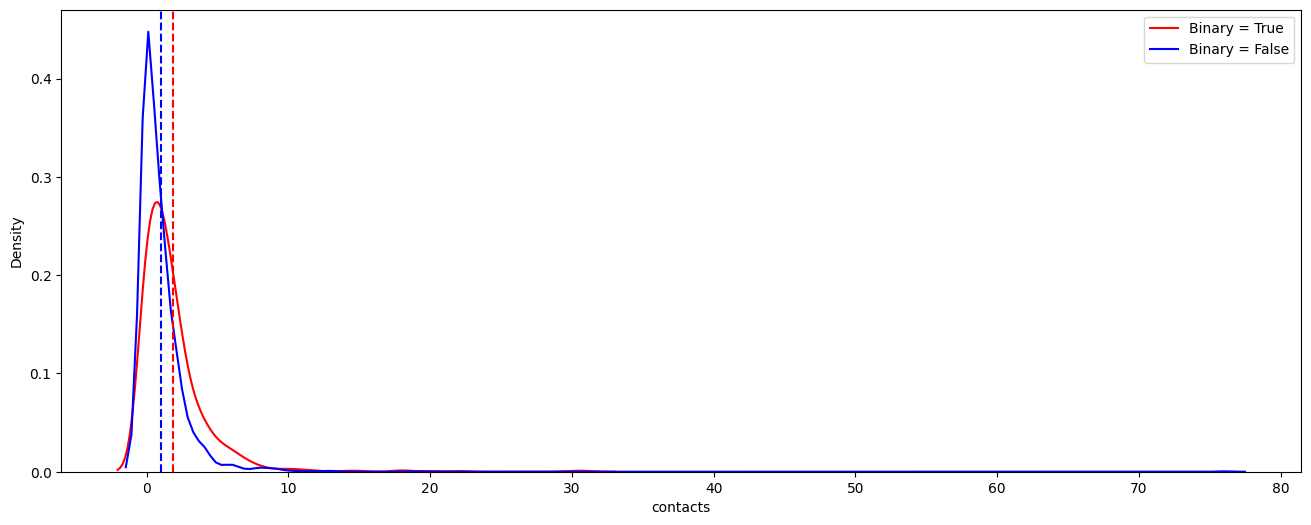

In [9]:
find_cat_quant_correlation(quant_value=df_data.contacts, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

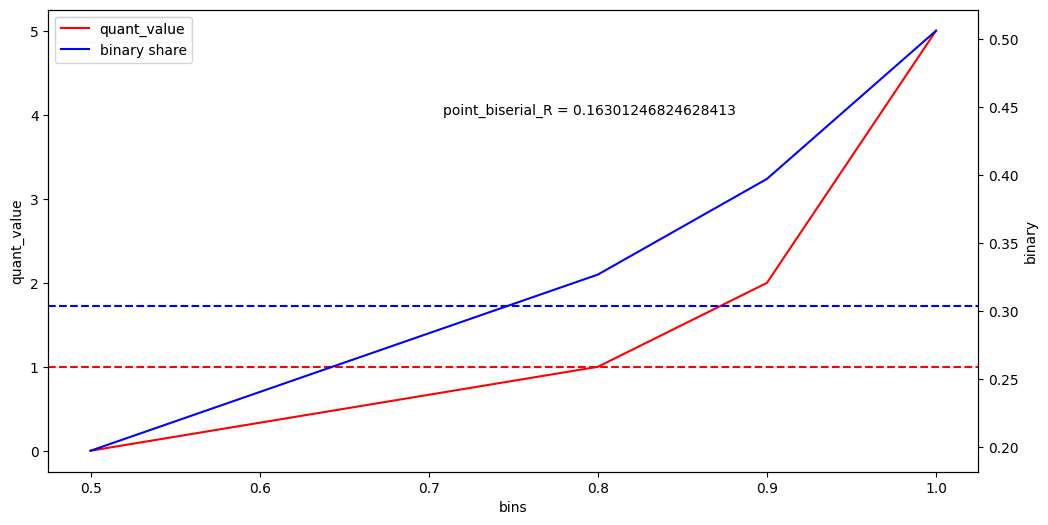

In [10]:
proxy_metrics_bins_analizer(quant_value=df_data.contacts, binary_mask=df_data.is_bought==1, step=0.1)

### last_7_views

Mean quant value for group (binary=1) = 95.6670403587444
Mean quant value for group (binary=0) = 61.97113502935421
Median quant value for group (binary=1) = 64.5
Median quant value for group (binary=0) = 41.0
Kruskal-Wallis H Test p-value = 6.868865275663376e-26
T-test p-value = 4.7838192325437344e-26
point biserial correlation = 0.19305473527105593


{'point biserial R': np.float64(0.19305473527105593),
 'kruskal_pval': np.float64(6.868865275663376e-26),
 'ttest_pval': np.float64(4.7838192325437344e-26)}

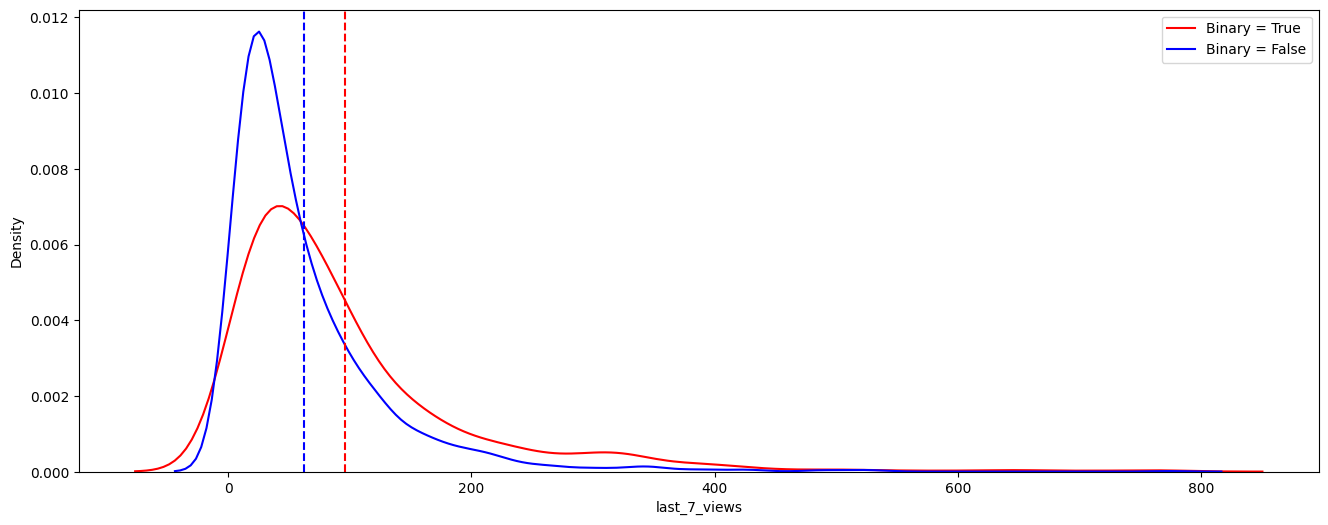

In [12]:
find_cat_quant_correlation(quant_value=df_data.last_7_views, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

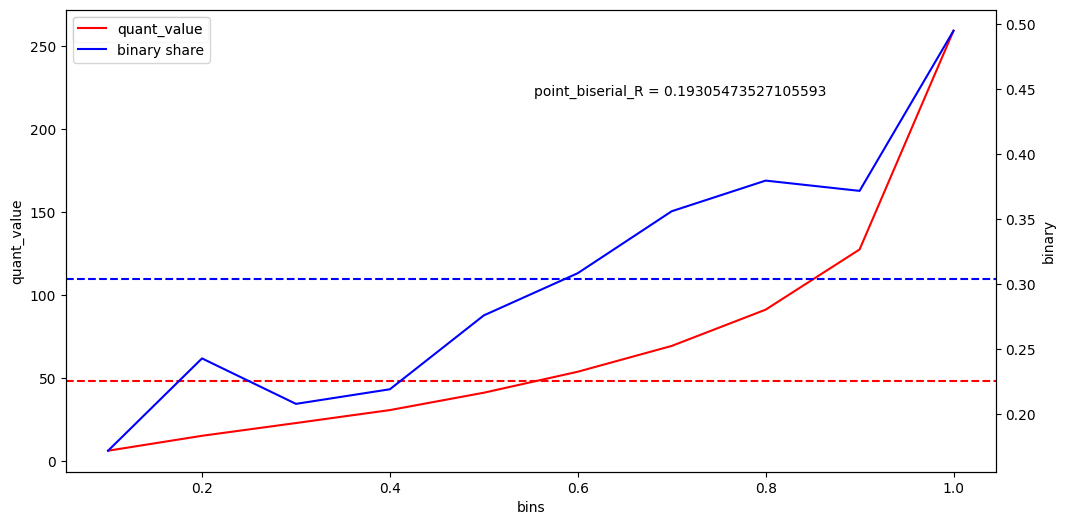

In [13]:
proxy_metrics_bins_analizer(quant_value=df_data.last_7_views, binary_mask=df_data.is_bought==1, step=0.1)

### last_3_views

Mean quant value for group (binary=1) = 69.24663677130044
Mean quant value for group (binary=0) = 31.101761252446185
Median quant value for group (binary=1) = 41.0
Median quant value for group (binary=0) = 17.0
Kruskal-Wallis H Test p-value = 6.132984107468055e-70
T-test p-value = 1.5345634949014947e-57
point biserial correlation = 0.2888844659292528


{'point biserial R': np.float64(0.2888844659292528),
 'kruskal_pval': np.float64(6.132984107468055e-70),
 'ttest_pval': np.float64(1.5345634949014947e-57)}

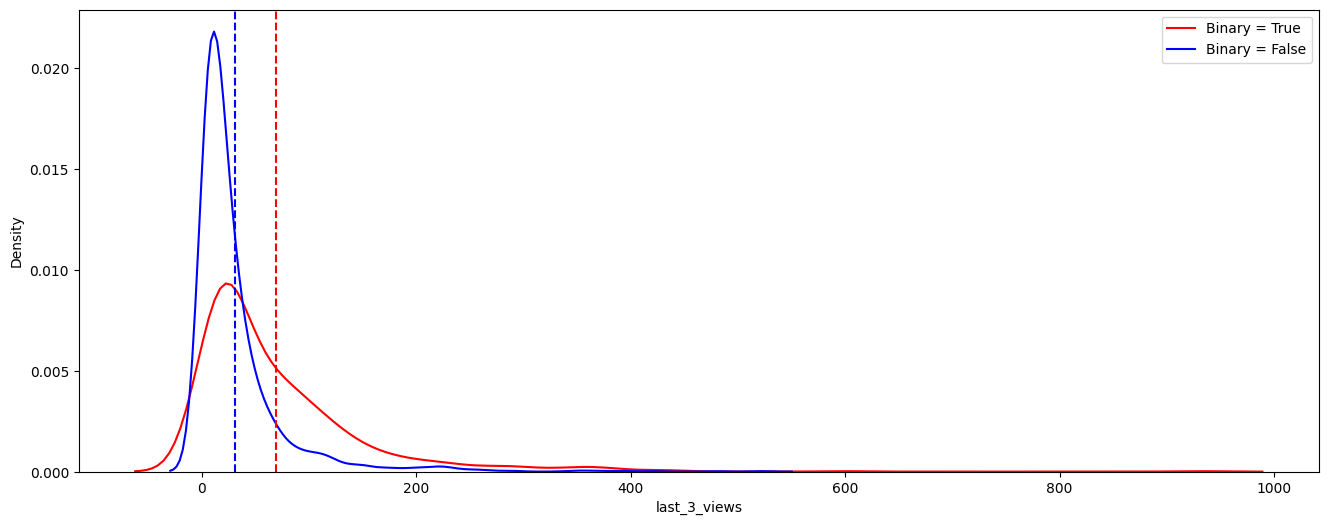

In [14]:
find_cat_quant_correlation(quant_value=df_data.last_3_views, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

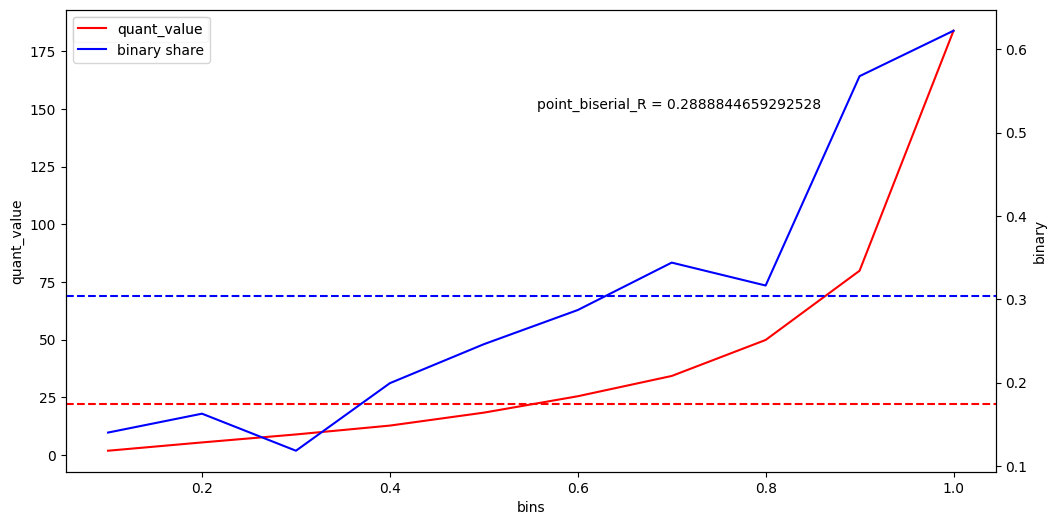

In [15]:
proxy_metrics_bins_analizer(quant_value=df_data.last_3_views, binary_mask=df_data.is_bought==1, step=0.1)

### last_7_contacts

Mean quant value for group (binary=1) = 1.5257847533632287
Mean quant value for group (binary=0) = 0.6521526418786693
Median quant value for group (binary=1) = 1.0
Median quant value for group (binary=0) = 0.0
Kruskal-Wallis H Test p-value = 1.0448910346397263e-61
T-test p-value = 5.603468395291586e-47
point biserial correlation = 0.26114359207113325


{'point biserial R': np.float64(0.26114359207113325),
 'kruskal_pval': np.float64(1.0448910346397263e-61),
 'ttest_pval': np.float64(5.603468395291586e-47)}

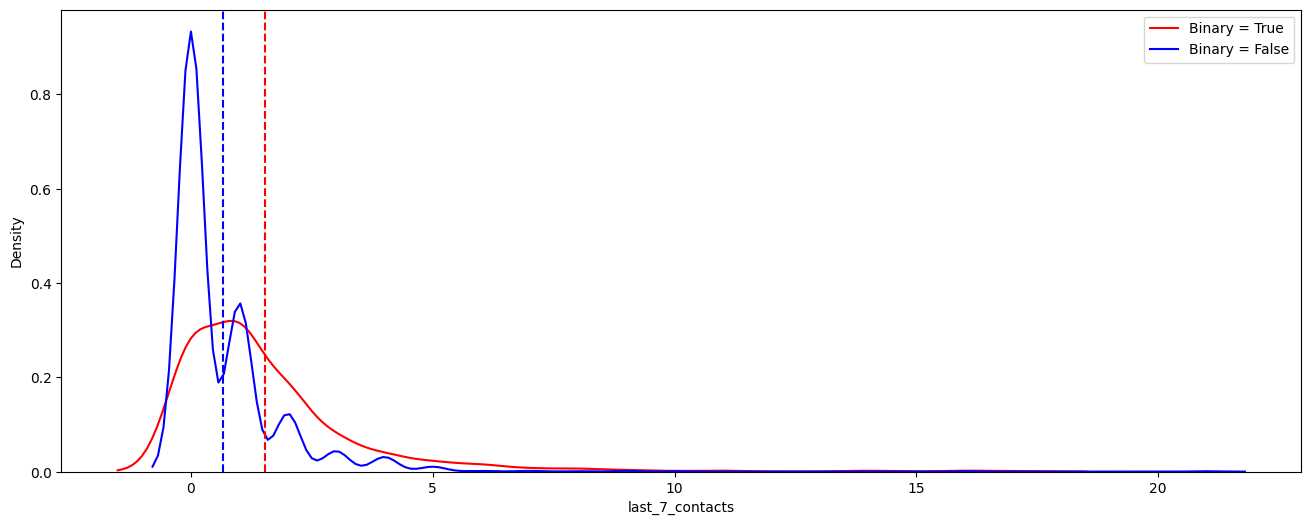

In [16]:
find_cat_quant_correlation(quant_value=df_data.last_7_contacts, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

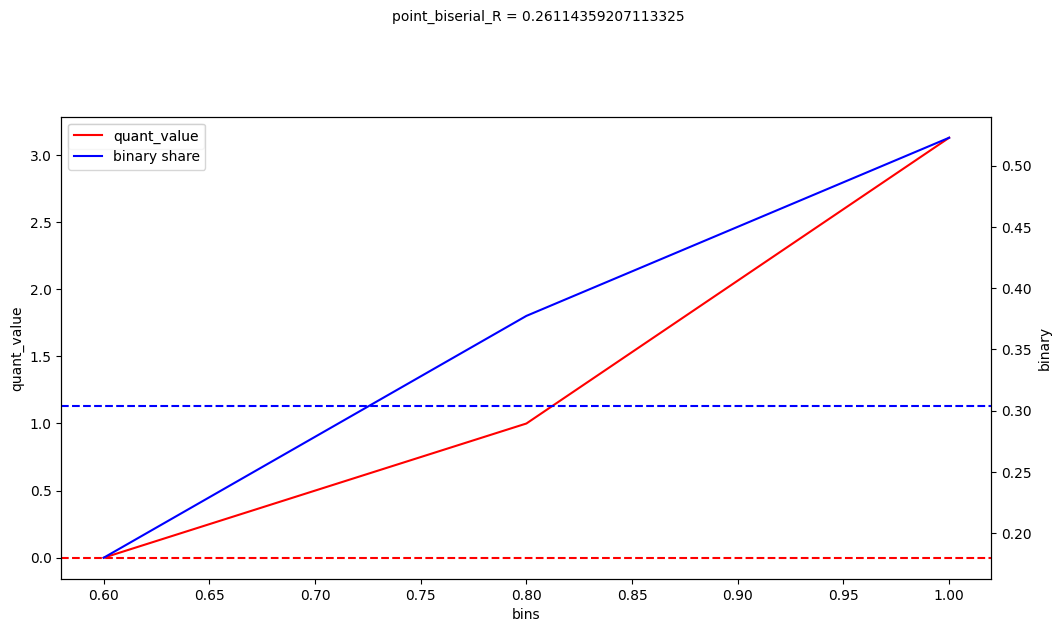

In [17]:
proxy_metrics_bins_analizer(quant_value=df_data.last_7_contacts, binary_mask=df_data.is_bought==1, step=0.1)

### last_3_contacts

Mean quant value for group (binary=1) = 1.15695067264574
Mean quant value for group (binary=0) = 0.3561643835616438
Median quant value for group (binary=1) = 1.0
Median quant value for group (binary=0) = 0.0
Kruskal-Wallis H Test p-value = 8.676789022138632e-83
T-test p-value = 5.574842534796481e-66
point biserial correlation = 0.3089893486384336


{'point biserial R': np.float64(0.3089893486384336),
 'kruskal_pval': np.float64(8.676789022138632e-83),
 'ttest_pval': np.float64(5.574842534796481e-66)}

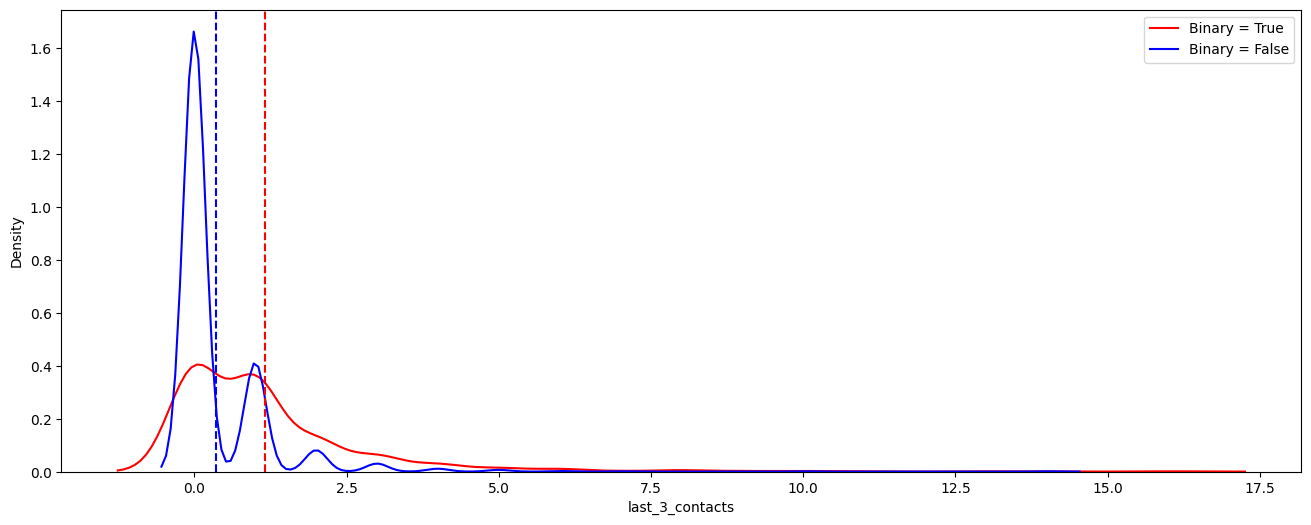

In [55]:
find_cat_quant_correlation(quant_value=df_data.last_3_contacts, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

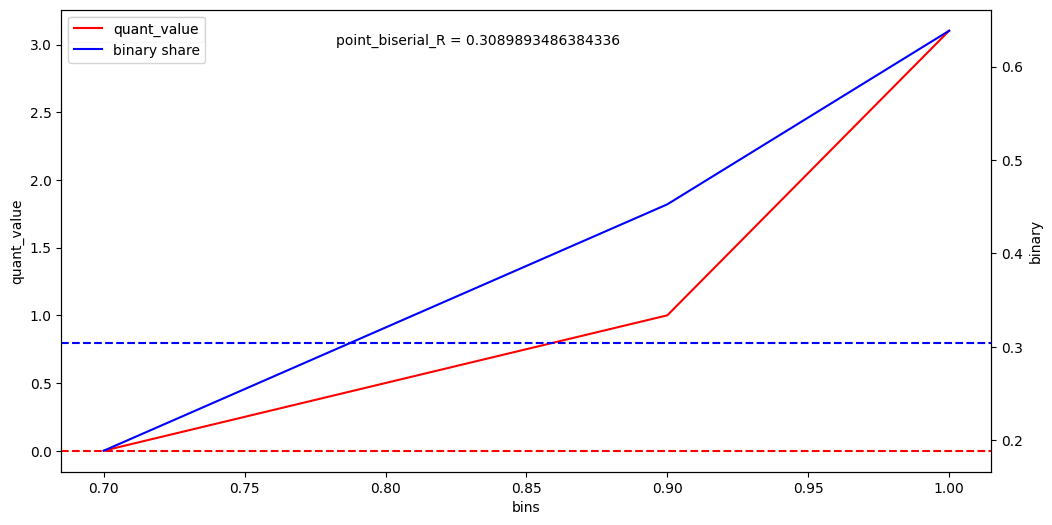

In [19]:
proxy_metrics_bins_analizer(quant_value=df_data.last_3_contacts, binary_mask=df_data.is_bought==1, step=0.1)

### live_days

Mean quant value for group (binary=1) = 10.147982062780269
Mean quant value for group (binary=0) = 12.383561643835616
Median quant value for group (binary=1) = 8.0
Median quant value for group (binary=0) = 8.0
Kruskal-Wallis H Test p-value = 3.1197003588212267e-21
T-test p-value = 1.1217120666549025e-09
point biserial correlation = -0.11210564728008264


{'point biserial R': np.float64(-0.11210564728008264),
 'kruskal_pval': np.float64(3.1197003588212267e-21),
 'ttest_pval': np.float64(1.1217120666549025e-09)}

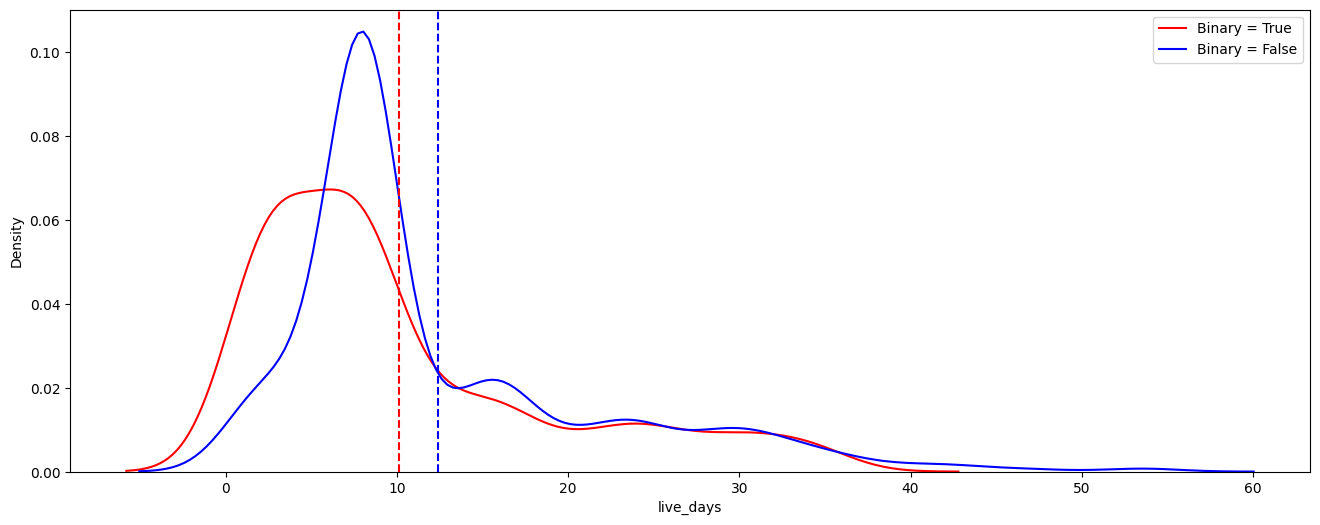

In [20]:
find_cat_quant_correlation(quant_value=df_data.live_days, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

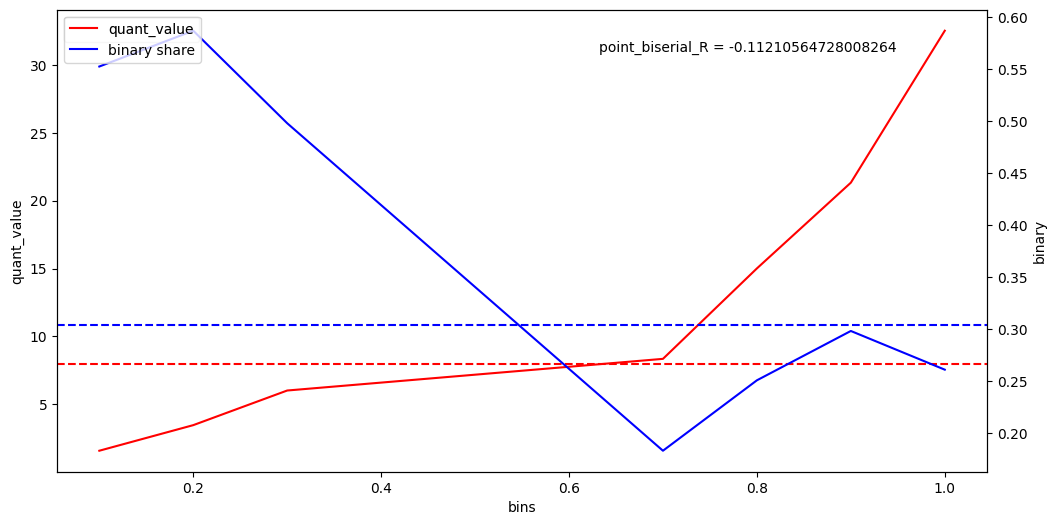

In [21]:
proxy_metrics_bins_analizer(quant_value=df_data.live_days, binary_mask=df_data.is_bought==1, step=0.1)

### messages_events

Mean quant value for group (binary=1) = 14.27354260089686
Mean quant value for group (binary=0) = 9.449119373776908
Median quant value for group (binary=1) = 9.0
Median quant value for group (binary=0) = 5.0
Kruskal-Wallis H Test p-value = 1.5301476752331674e-19
T-test p-value = 1.88510939348689e-15
point biserial correlation = 0.14597133698165166


{'point biserial R': np.float64(0.14597133698165166),
 'kruskal_pval': np.float64(1.5301476752331674e-19),
 'ttest_pval': np.float64(1.88510939348689e-15)}

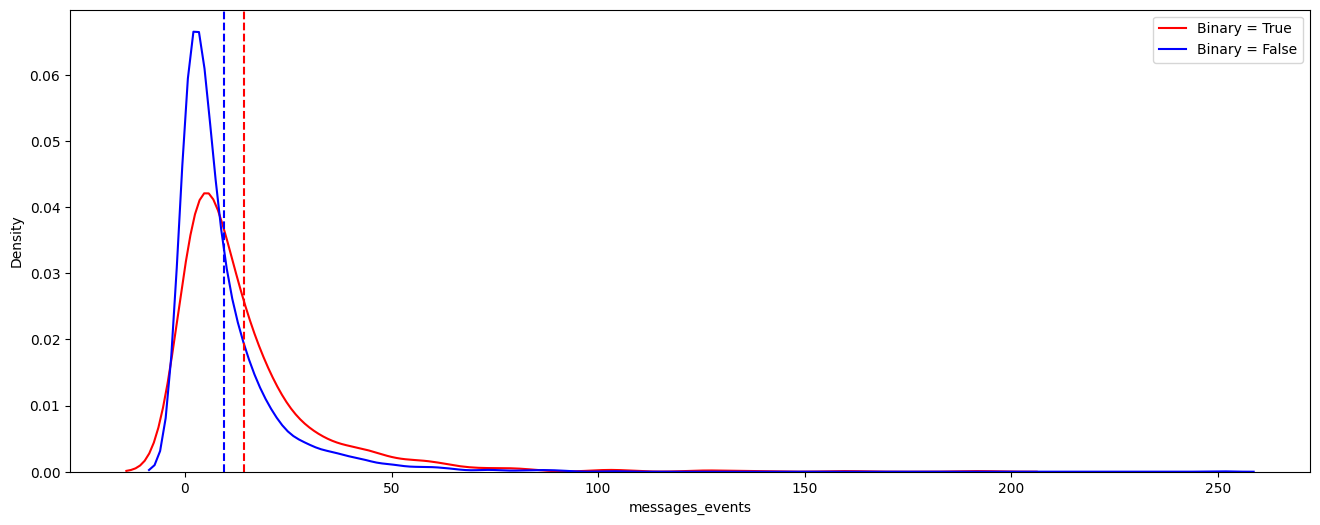

In [22]:
find_cat_quant_correlation(quant_value=df_data.messages_events, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

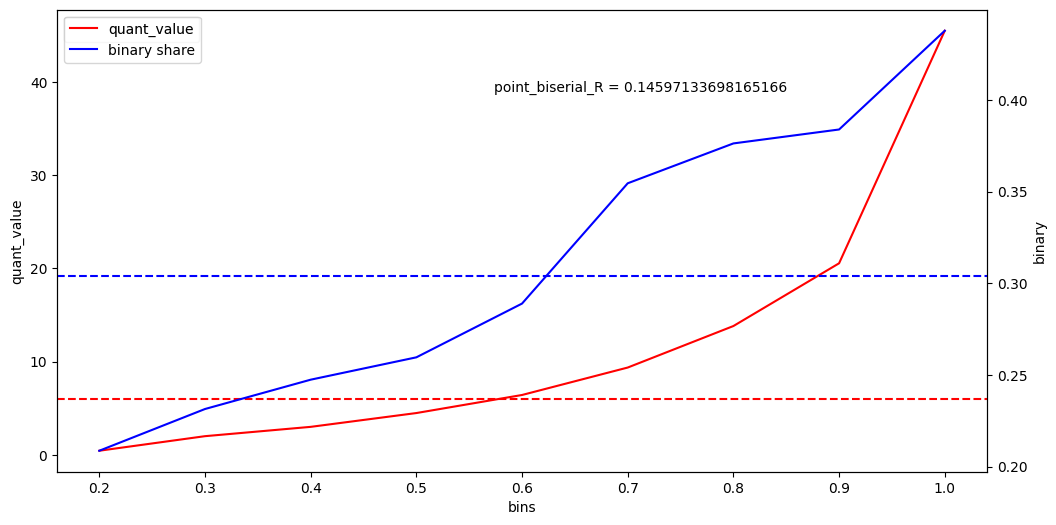

In [23]:
proxy_metrics_bins_analizer(quant_value=df_data.messages_events, binary_mask=df_data.is_bought==1, step=0.1)

### add_to_favor_events

Mean quant value for group (binary=1) = 27.495515695067265
Mean quant value for group (binary=0) = 11.83023483365949
Median quant value for group (binary=1) = 14.0
Median quant value for group (binary=0) = 5.0
Kruskal-Wallis H Test p-value = 9.374761642064984e-63
T-test p-value = 6.376740607072923e-41
point biserial correlation = 0.24359900401524248


{'point biserial R': np.float64(0.24359900401524248),
 'kruskal_pval': np.float64(9.374761642064984e-63),
 'ttest_pval': np.float64(6.376740607072923e-41)}

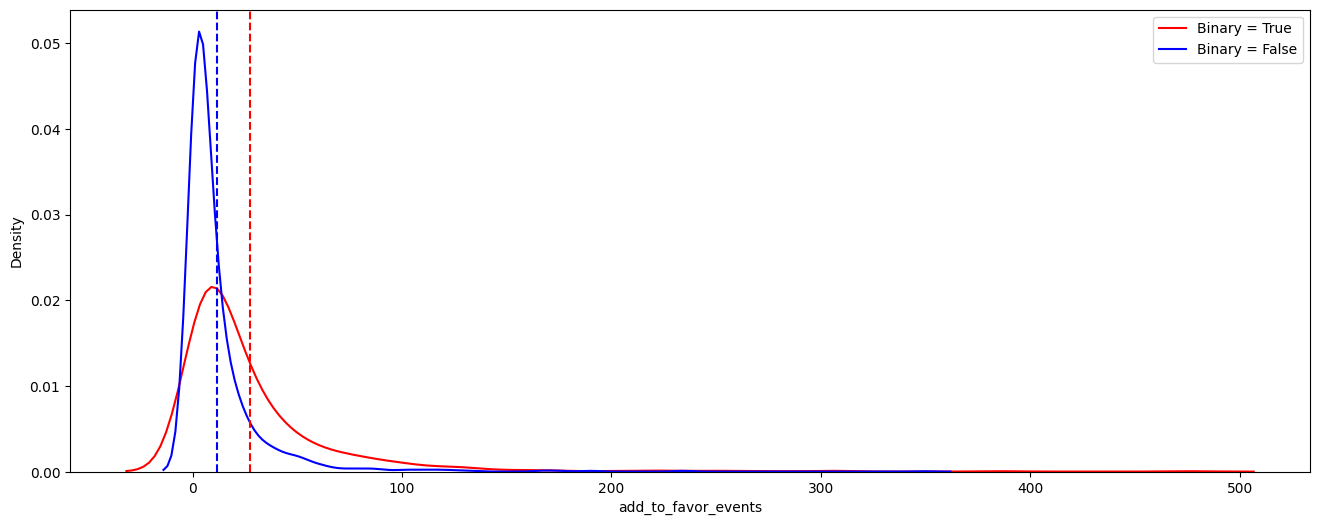

In [30]:
find_cat_quant_correlation(quant_value=df_data.add_to_favor_events, binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

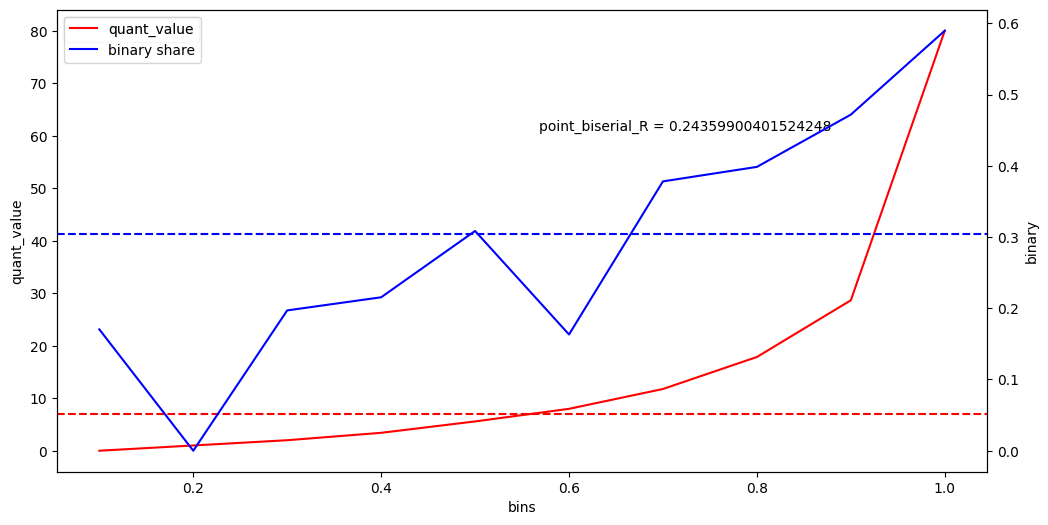

In [28]:
proxy_metrics_bins_analizer(quant_value=df_data.add_to_favor_events, binary_mask=df_data.is_bought==1, step=0.1)

### contacts / view

Mean quant value for group (binary=1) = 0.0159080166932358
Mean quant value for group (binary=0) = 0.009478740022677873
Median quant value for group (binary=1) = 0.011363636363636364
Median quant value for group (binary=0) = 0.0
Kruskal-Wallis H Test p-value = 7.017560466954048e-32
T-test p-value = 3.1738858251804734e-21
point biserial correlation = 0.17328114556978214


{'point biserial R': np.float64(0.17328114556978214),
 'kruskal_pval': np.float64(7.017560466954048e-32),
 'ttest_pval': np.float64(3.1738858251804734e-21)}

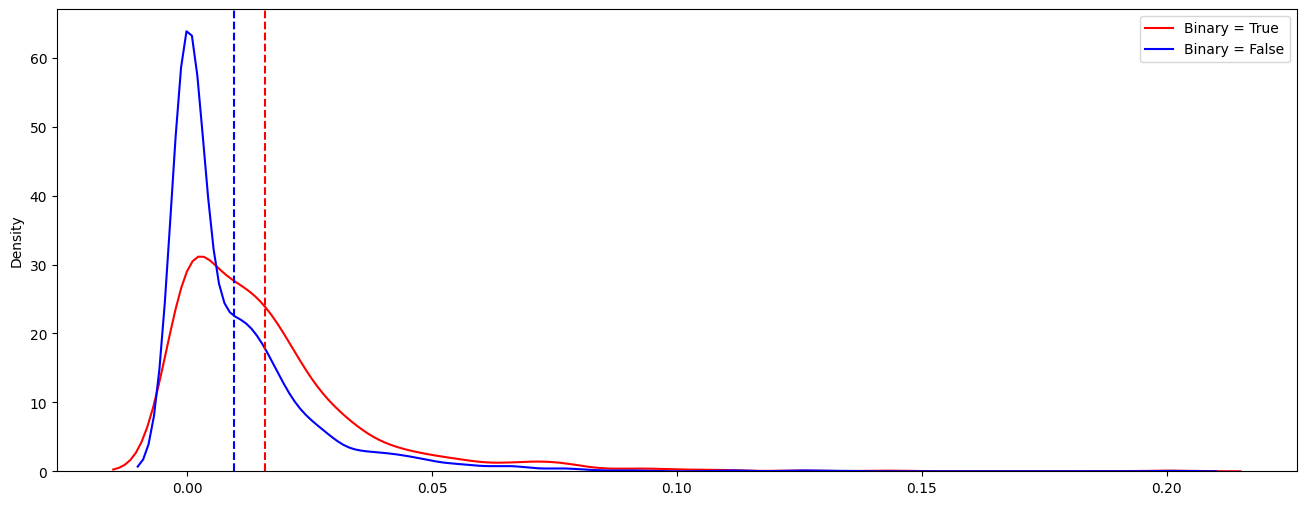

In [38]:
find_cat_quant_correlation(quant_value=(df_data.contacts) / (df_data.views+1), binary_mask=df_data.is_bought==1, plot=True, print_inference=True)

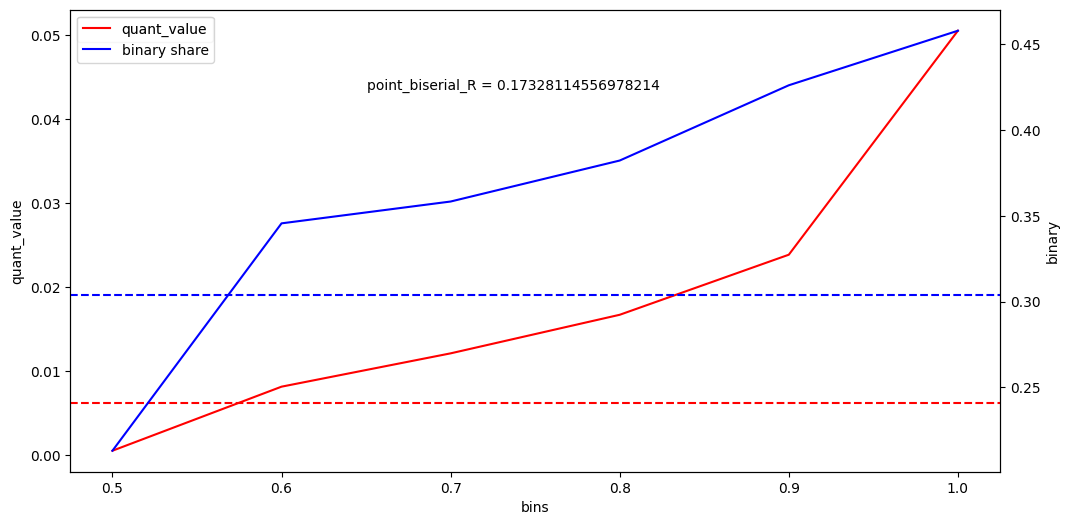

In [39]:
proxy_metrics_bins_analizer(quant_value=df_data.contacts / (df_data.views+1), binary_mask=df_data.is_bought==1, step=0.1)

### standartized: last_3_contacts

Mean quant value for group (binary=1) = 0.0710848827692893
Mean quant value for group (binary=0) = -0.3734772279546443
Median quant value for group (binary=1) = 0.018830856982662153
Median quant value for group (binary=0) = -0.571015132613761
Kruskal-Wallis H Test p-value = 3.2710308856497143e-85
T-test p-value = 1.8488754815128645e-104
point biserial correlation = 0.3851759586998848


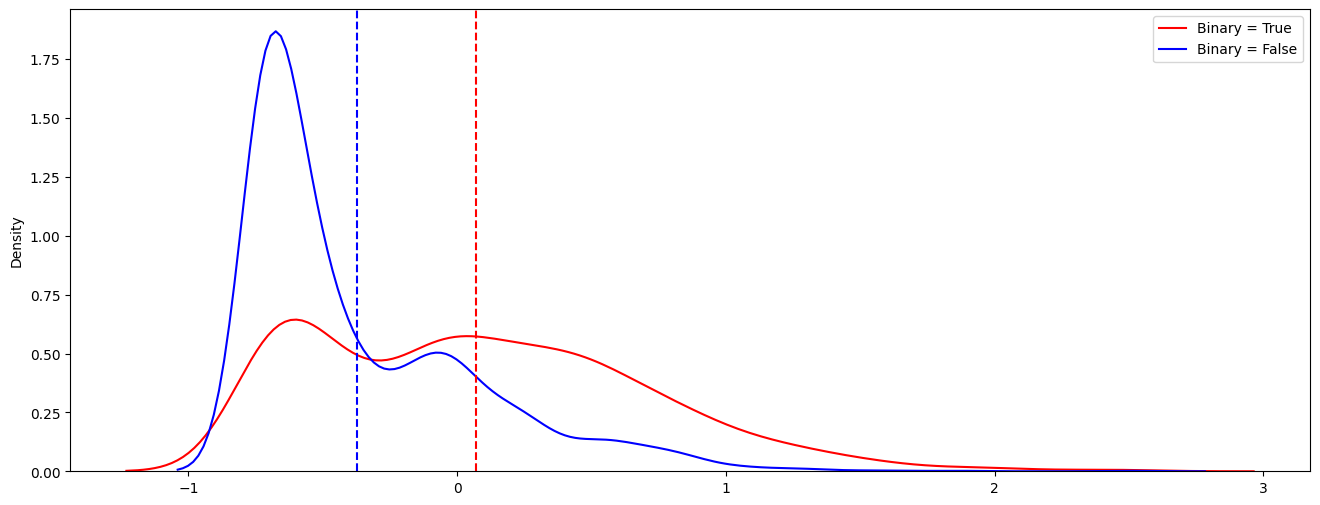

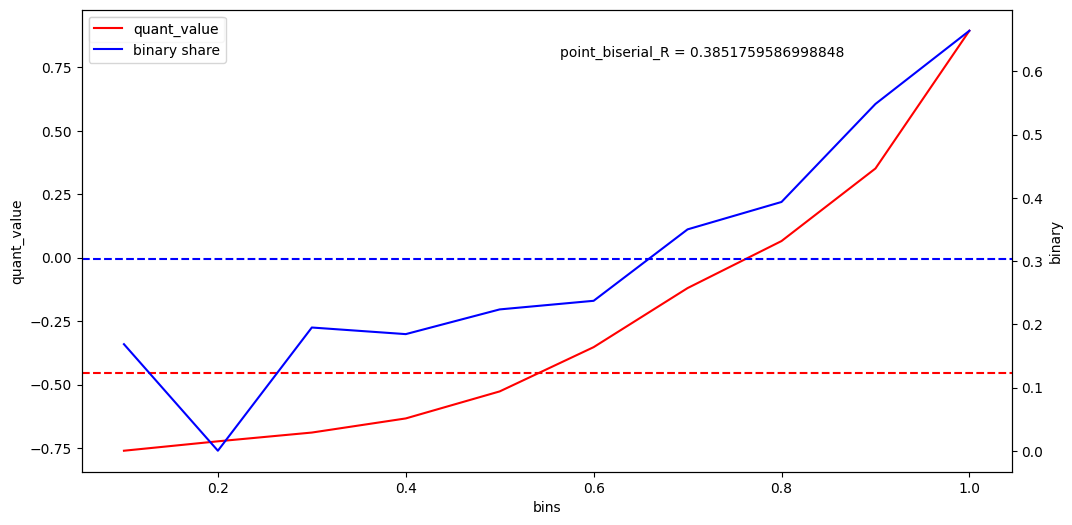

In [57]:
find_cat_quant_correlation(
    quant_value=np.log(standartized(df_data.last_3_contacts)+1)*0.5+np.log(standartized(df_data.add_to_favor_events)+1)*0.5,
    binary_mask=df_data.is_bought==1, plot=True, print_inference=True
)

proxy_metrics_bins_analizer(
    quant_value=np.log(standartized(df_data.last_3_contacts)+1)*0.5+np.log(standartized(df_data.add_to_favor_events)+1)*0.5,
    binary_mask=df_data.is_bought==1, step=0.1
)

### last_3_contacts / last_3_view

Mean quant value for group (binary=1) = 0.017050520899235123
Mean quant value for group (binary=0) = 0.008313830428186569
Median quant value for group (binary=1) = 0.010507913139492087
Median quant value for group (binary=0) = 0.0
Kruskal-Wallis H Test p-value = 1.9902466587034692e-63
T-test p-value = 7.012594373246684e-24
point biserial correlation = 0.18444746536589635


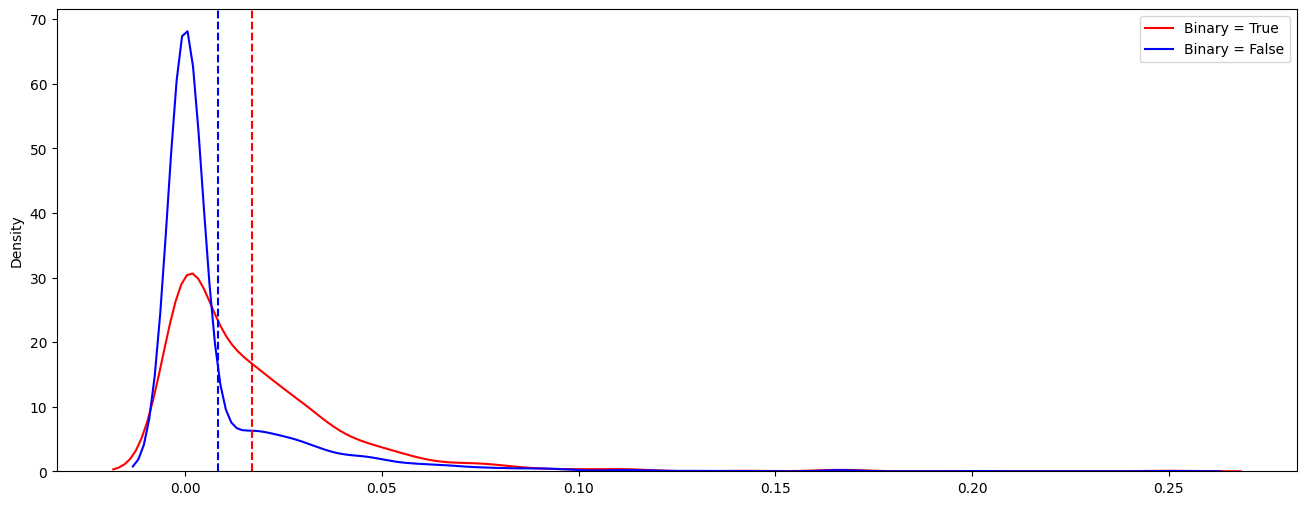

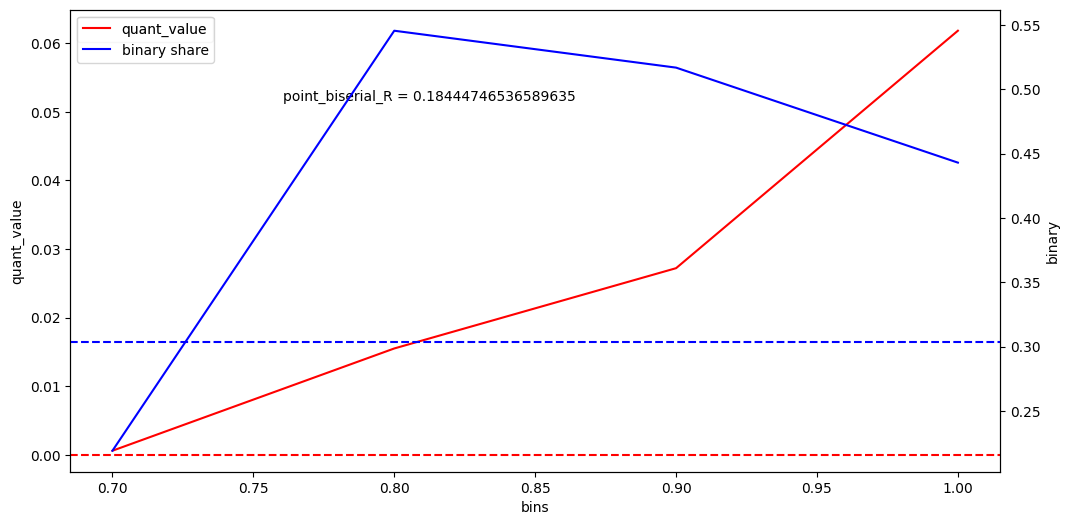

In [51]:
find_cat_quant_correlation(quant_value=(df_data.last_3_contacts) / (df_data.last_3_views+1), binary_mask=df_data.is_bought==1, plot=True, print_inference=True)
proxy_metrics_bins_analizer(quant_value=(df_data.last_3_contacts) / (df_data.last_3_views+1), binary_mask=df_data.is_bought==1, step=0.1)

## cramer V

In [71]:
# доля бесконтактных
(df_data.last_3_views== 0).sum() / len(df_data)

np.float64(0.006471389645776567)

In [72]:
df_data.last_3_views.median()

np.float64(22.0)

In [74]:
# для примера давайте рассмотрим корреляцию между следующими метриками
confusion_matrix = pd.crosstab(df_data.is_bought==1, df_data.last_3_views>22)
cramers_v(confusion_matrix.values)

np.float64(0.27774681448716554)

Maximum Cramer V = 0.31920141067093866
Maximum Cramer V quant value =  60.0


{'max_cramer_v': np.float64(0.31920141067093866),
 'max_corr_quant_value': np.float64(60.0)}

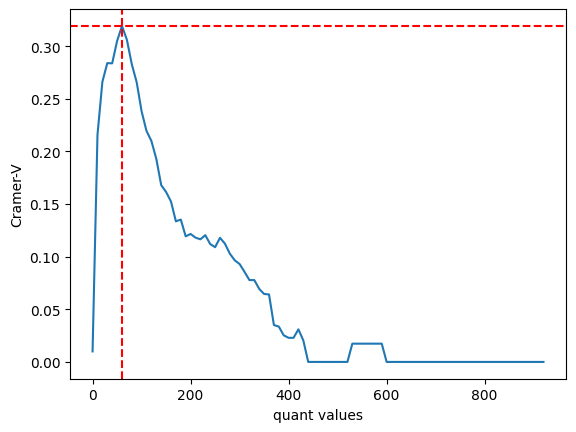

In [78]:
max_cramerv_corr_finder(df_data.last_3_views, df_data.is_bought==1, plot=True, print_inference=True, step=10)

## power and sign 